# PS3 Problem 1: A Simple Neural Network

This problem explores neural networks with different activation functions and their capabilities to classify non-linearly separable data.

## Problem Setup

We have a neural network with:
- 2 input features (x₁, x₂)
- 3 hidden units with activation function σ
- 1 output unit with sigmoid activation
- Target: classify XOR-like pattern where points inside a triangle are class 0, outside are class 1

The network equations are:
- z⁽¹⁾ = W⁽¹⁾x + W₀⁽¹⁾
- h = σ(z⁽¹⁾)
- z⁽²⁾ = W⁽²⁾h + W₀⁽²⁾  
- o = σ(z⁽²⁾)
- Loss: ℓ = (1/m) Σᵢ(oᵢ - yᵢ)²

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json
from matplotlib.patches import Polygon
from matplotlib.colors import ListedColormap

# Set up plotting style
plt.style.use('default')
%matplotlib inline

## Part (a): Backpropagation Gradient Derivation

**Task**: Derive the gradient ∂J/∂w₁,₂⁽¹⁾ using the chain rule.

For a single training example, we need to apply the chain rule:

∂J/∂w₁,₂⁽¹⁾ = ∂J/∂o × ∂o/∂z⁽²⁾ × ∂z⁽²⁾/∂h₂ × ∂h₂/∂z₂⁽¹⁾ × ∂z₂⁽¹⁾/∂w₁,₂⁽¹⁾

Let's compute each term:

1. **∂J/∂o**: Since J = (o - y)², we have ∂J/∂o = 2(o - y)

2. **∂o/∂z⁽²⁾**: Since o = σ(z⁽²⁾) and σ'(z) = σ(z)(1-σ(z)), we have ∂o/∂z⁽²⁾ = o(1-o)

3. **∂z⁽²⁾/∂h₂**: Since z⁽²⁾ = w₀⁽²⁾ + w₁⁽²⁾h₁ + w₂⁽²⁾h₂ + w₃⁽²⁾h₃, we have ∂z⁽²⁾/∂h₂ = w₂⁽²⁾

4. **∂h₂/∂z₂⁽¹⁾**: Since h₂ = σ(z₂⁽¹⁾), we have ∂h₂/∂z₂⁽¹⁾ = h₂(1-h₂)

5. **∂z₂⁽¹⁾/∂w₁,₂⁽¹⁾**: Since z₂⁽¹⁾ = w₀,₂⁽¹⁾ + w₁,₂⁽¹⁾x₁ + w₂,₂⁽¹⁾x₂, we have ∂z₂⁽¹⁾/∂w₁,₂⁽¹⁾ = x₁

**Final Result**:
∂J/∂w₁,₂⁽¹⁾ = 2(o - y) × o(1-o) × w₂⁽²⁾ × h₂(1-h₂) × x₁

For the full dataset with m examples, the gradient descent update rule is:

**w₁,₂⁽¹⁾ := w₁,₂⁽¹⁾ - α × (2/m) Σᵢ₌₁ᵐ [(o⁽ⁱ⁾ - y⁽ⁱ⁾) × o⁽ⁱ⁾(1-o⁽ⁱ⁾) × w₂⁽²⁾ × h₂⁽ⁱ⁾(1-h₂⁽ⁱ⁾) × x₁⁽ⁱ⁾]**

## Part (b): Neural Network with Step Activation Function

**Triangle Definition**:
Our triangle is defined by three boundary lines:
- x₁ = 0.5
- x₂ = 0.5
- x₁ + x₂ = 4

Points that satisfy all of these inequalities are inside the triangle:
- x₁ ≥ 0.5
- x₂ ≥ 0.5
- x₁ + x₂ ≤ 4

Now we'll implement a neural network with a step activation function to classify points as being inside (class 0) or outside (class 1) this triangle.

In [6]:
def step_activation(z):
    """Step activation function: 1 if z >= 0, 0 otherwise"""
    return np.where(z >= 0, 1, 0)

def forward_pass_step(x, W1, b1, W2, b2):
    """
    Forward pass for neural network with step activation function
    
    Parameters:
    x: Input features [m, 2]
    W1: First layer weights [3, 2]
    b1: First layer bias [3, 1]
    W2: Second layer weights [1, 3]
    b2: Second layer bias [1, 1]
    
    Returns:
    o: Output prediction [m, 1]
    h: Hidden layer activations [m, 3]
    """
    # First layer
    z1 = np.dot(x, W1.T) + b1.T  # [m, 3]
    h = step_activation(z1)      # [m, 3]
    
    # Second layer
    z2 = np.dot(h, W2.T) + b2    # [m, 1]
    o = step_activation(z2)      # [m, 1]
    
    return o, h

### Deriving Weights from Triangle Equations

Our triangle is defined by three linear inequalities:
1. x₁ ≥ 0.5
2. x₂ ≥ 0.5
3. x₁ + x₂ ≤ 4

For our neural network with step activation functions, we want each hidden unit to represent one of these boundary conditions:

**Hidden Unit 1 (h₁)**: Will check if x₁ ≥ 0.5
- We need z₁⁽¹⁾ = w₁,₁⁽¹⁾x₁ + w₂,₁⁽¹⁾x₂ + w₀,₁⁽¹⁾ ≥ 0 when x₁ ≥ 0.5
- This becomes: w₁,₁⁽¹⁾x₁ + w₂,₁⁽¹⁾x₂ + w₀,₁⁽¹⁾ = x₁ - 0.5 ≥ 0
- So, w₁,₁⁽¹⁾ = 1, w₂,₁⁽¹⁾ = 0, w₀,₁⁽¹⁾ = -0.5

**Hidden Unit 2 (h₂)**: Will check if x₂ ≥ 0.5
- We need z₂⁽¹⁾ = w₁,₂⁽¹⁾x₁ + w₂,₂⁽¹⁾x₂ + w₀,₂⁽¹⁾ ≥ 0 when x₂ ≥ 0.5
- This becomes: w₁,₂⁽¹⁾x₁ + w₂,₂⁽¹⁾x₂ + w₀,₂⁽¹⁾ = x₂ - 0.5 ≥ 0
- So, w₁,₂⁽¹⁾ = 0, w₂,₂⁽¹⁾ = 1, w₀,₂⁽¹⁾ = -0.5

**Hidden Unit 3 (h₃)**: Will check if x₁ + x₂ ≤ 4
- We need z₃⁽¹⁾ = w₁,₃⁽¹⁾x₁ + w₂,₃⁽¹⁾x₂ + w₀,₃⁽¹⁾ ≥ 0 when x₁ + x₂ ≤ 4
- This becomes: w₁,₃⁽¹⁾x₁ + w₂,₃⁽¹⁾x₂ + w₀,₃⁽¹⁾ = -(x₁ + x₂) + 4 ≥ 0
- So, w₁,₃⁽¹⁾ = -1, w₂,₃⁽¹⁾ = -1, w₀,₃⁽¹⁾ = 4

For the output layer, we need all three conditions to be true (h₁ = 1, h₂ = 1, h₃ = 1) for a point to be inside the triangle (class 0). 
Since our network outputs 1 for points outside the triangle, we want:
- o = 0 when all h₁ = h₂ = h₃ = 1 (inside triangle)
- o = 1 otherwise (outside triangle)

This means we want the output to be 1 unless all hidden units are 1, which we can achieve with:
- w₁⁽²⁾ = -1, w₂⁽²⁾ = -1, w₃⁽²⁾ = -1, w₀⁽²⁾ = 2

With these weights, z⁽²⁾ = -h₁ - h₂ - h₃ + 2, which gives:
- If all h₁ = h₂ = h₃ = 1, then z⁽²⁾ = -1, making o = 0 (inside triangle)
- Otherwise, z⁽²⁾ ≥ 0, making o = 1 (outside triangle)

In [9]:
# Implement the derived weights for step activation function
W1_step = np.array([
    [1, 0],    # Hidden unit 1: x₁ ≥ 0.5
    [0, 1],    # Hidden unit 2: x₂ ≥ 0.5
    [-1, -1]   # Hidden unit 3: x₁ + x₂ ≤ 4
])  # Shape: [3, 2]

b1_step = np.array([[-0.5], [-0.5], [4]]) # Shape: [3, 1]

W2_step = np.array([[-1, -1, -1]])  # Shape: [1, 3]
b2_step = np.array([[2]])  # Shape: [1, 1]

print("First layer weights (W1):")
print(W1_step)
print("\nFirst layer bias (b1):")
print(b1_step)
print("\nSecond layer weights (W2):")
print(W2_step)
print("\nSecond layer bias (b2):")
print(b2_step)

First layer weights (W1):
[[ 1  0]
 [ 0  1]
 [-1 -1]]

First layer bias (b1):
[[-0.5]
 [-0.5]
 [ 4. ]]

Second layer weights (W2):
[[-1 -1 -1]]

Second layer bias (b2):
[[2]]


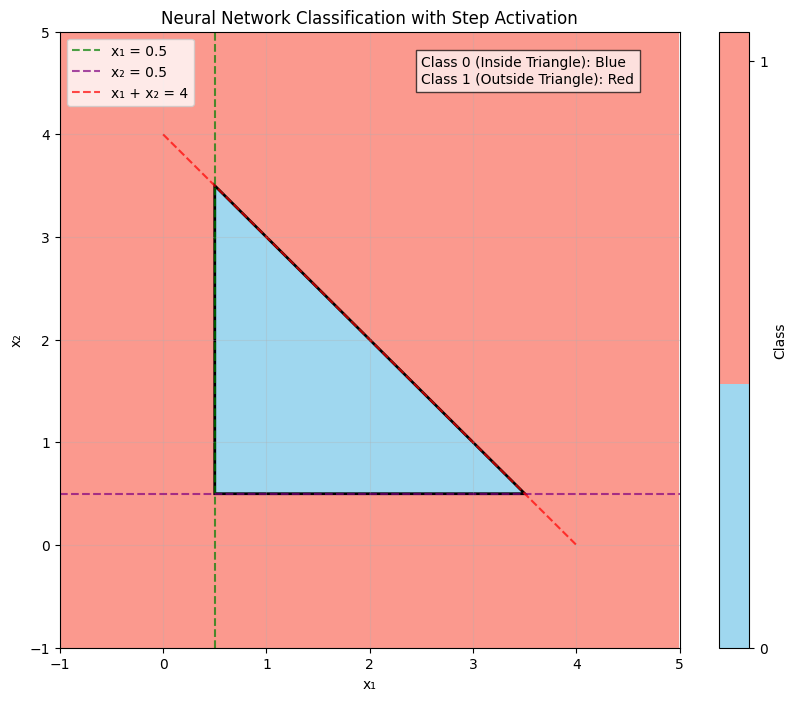

In [10]:
# Visualize the classification boundary
def visualize_classification(W1, b1, W2, b2, activation_fn=step_activation):
    # Create a grid of points
    x1_min, x1_max = -1, 5
    x2_min, x2_max = -1, 5
    h = 0.01
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h),
                          np.arange(x2_min, x2_max, h))
    
    # Prepare data for the neural network
    grid_points = np.c_[xx1.ravel(), xx2.ravel()]
    
    if activation_fn == step_activation:
        # Use our forward pass function for step activation
        predictions, _ = forward_pass_step(grid_points, W1, b1, W2, b2)
    else:
        # For sigmoid or other activation functions, implement as needed
        pass
    
    # Reshape the predictions
    predictions = predictions.reshape(xx1.shape)
    
    # Plot the decision boundary
    plt.figure(figsize=(10, 8))
    plt.contourf(xx1, xx2, predictions, cmap=ListedColormap(['skyblue', 'salmon']), alpha=0.8)
    
    # Plot the triangle
    triangle_points = np.array([[0.5, 0.5], [0.5, 3.5], [3.5, 0.5]])
    triangle = Polygon(triangle_points, fill=False, edgecolor='black', linewidth=2)
    plt.gca().add_patch(triangle)
    
    # Add contour lines for each hidden unit
    x1_values = np.linspace(x1_min, x1_max, 100)
    
    # Line 1: x₁ = 0.5
    plt.axvline(x=0.5, color='green', linestyle='--', alpha=0.7, label='x₁ = 0.5')
    
    # Line 2: x₂ = 0.5
    plt.axhline(y=0.5, color='purple', linestyle='--', alpha=0.7, label='x₂ = 0.5')
    
    # Line 3: x₁ + x₂ = 4
    x1_line3 = np.linspace(0, 4, 100)
    x2_line3 = 4 - x1_line3
    plt.plot(x1_line3, x2_line3, 'r--', alpha=0.7, label='x₁ + x₂ = 4')
    
    # Customize the plot
    plt.xlim(x1_min, x1_max)
    plt.ylim(x2_min, x2_max)
    plt.xlabel('x₁')
    plt.ylabel('x₂')
    plt.title('Neural Network Classification with Step Activation')
    plt.legend()
    plt.colorbar(ticks=[0, 1], label='Class')
    plt.grid(True, alpha=0.3)
    
    # Add explanatory text
    plt.text(2.5, 4.5, 'Class 0 (Inside Triangle): Blue\nClass 1 (Outside Triangle): Red', 
             bbox=dict(facecolor='white', alpha=0.7))
    
    plt.show()

# Visualize the step function neural network's classification
visualize_classification(W1_step, b1_step, W2_step, b2_step)

### Summary of Weight Derivation Process

The key to solving this problem was recognizing that with a step activation function, we can directly translate the linear boundary equations of the triangle into the weights of our neural network.

**Step 1: Identify the boundary conditions**
We identified three boundary equations:
- x₁ = 0.5 → x₁ ≥ 0.5 for points inside
- x₂ = 0.5 → x₂ ≥ 0.5 for points inside
- x₁ + x₂ = 4 → x₁ + x₂ ≤ 4 for points inside

**Step 2: Translate each boundary to a hidden unit**
For each hidden unit to represent a boundary condition, we needed to ensure:
- z ≥ 0 (which gives h = 1) when the corresponding inequality is satisfied
- z < 0 (which gives h = 0) otherwise

**Step 3: Determine the first layer weights (W1 and b1)**
Each hidden unit corresponds to one boundary:
- h₁ = 1 when x₁ ≥ 0.5, so we need z₁⁽¹⁾ = x₁ - 0.5 ≥ 0
- h₂ = 1 when x₂ ≥ 0.5, so we need z₂⁽¹⁾ = x₂ - 0.5 ≥ 0
- h₃ = 1 when x₁ + x₂ ≤ 4, so we need z₃⁽¹⁾ = -(x₁ + x₂) + 4 ≥ 0

**Step 4: Determine the second layer weights (W2 and b2)**
For the output layer, we need:
- o = 0 (inside triangle) when all h₁ = h₂ = h₃ = 1
- o = 1 (outside triangle) when any of the hidden units is 0

We achieved this with:
- z⁽²⁾ = -h₁ - h₂ - h₃ + 2
- When all h = 1, z⁽²⁾ = -1 giving o = 0
- When any h = 0, z⁽²⁾ ≥ 0 giving o = 1

This is how we directly derived the weights from the geometric constraints of the triangle.

## Part (c): Linear Activation Functions

In this part, we investigate the capabilities of the neural network when the hidden layer uses linear activation functions (`f(x) = x`) and the output layer uses a step function.

The core question is: **Can this network classify the dataset with 100% accuracy?**

To answer this, let's first understand the mathematical nature of this specific network architecture.

The output of the hidden layer neurons `h1`, `h2`, and `h3` are linear combinations of the inputs `x1` and `x2` (plus a bias). Since the activation function is linear (or the identity function), the output of the hidden layer is still a linear combination of the inputs.

The output neuron `o` takes a linear combination of the hidden layer outputs. A linear combination of linear combinations is itself a linear combination.

So, the input to the final step function is just a linear combination of the original inputs `x1` and `x2`. This means the entire network, despite the hidden layer, simplifies to a single perceptron with a linear decision boundary.

`output = step(W1*x1 + W2*x2 + B)`

A single perceptron can only achieve 100% accuracy if the dataset is **linearly separable**. Let's visualize the dataset to see if that's the case.

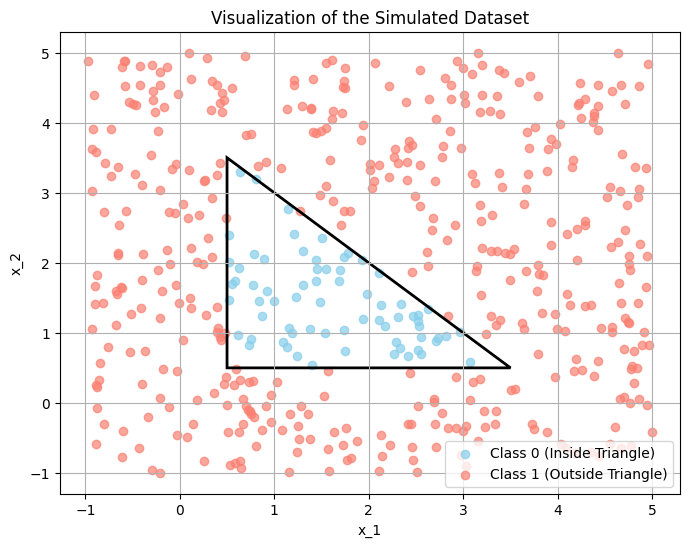

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

# Generate synthetic data
np.random.seed(0)
x_coords = np.random.uniform(-1, 5, 500)
y_coords = np.random.uniform(-1, 5, 500)
points = np.vstack((x_coords, y_coords)).T

# Classify points based on triangle boundaries
# Class 0: inside the triangle (x1 >= 0.5, x2 >= 0.5, x1+x2 <= 4)
# Class 1: outside the triangle
inside_mask = (points[:, 0] >= 0.5) & (points[:, 1] >= 0.5) & (points[:, 0] + points[:, 1] <= 4)

class_0_points = points[inside_mask]
class_1_points = points[~inside_mask]

# Create a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(class_0_points[:, 0], class_0_points[:, 1], label='Class 0 (Inside Triangle)', alpha=0.7, c='skyblue')
plt.scatter(class_1_points[:, 0], class_1_points[:, 1], label='Class 1 (Outside Triangle)', alpha=0.7, c='salmon')

# Plot the triangle boundaries for clarity
triangle_points = np.array([[0.5, 0.5], [0.5, 3.5], [3.5, 0.5]])
triangle = Polygon(triangle_points, fill=False, edgecolor='black', linewidth=2)
plt.gca().add_patch(triangle)

plt.title('Visualization of the Simulated Dataset')
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.legend()
plt.grid(True)
plt.show()

### Conclusion

As the plot above clearly shows, the dataset is **not linearly separable**. The data points for "Class 0" form a triangle, and the points for "Class 1" surround it.

You cannot draw a single straight line to separate a convex shape (the triangle) from the area outside of it. A linear classifier can only separate the plane into two half-planes.

Since the neural network with linear hidden units is equivalent to a linear classifier, it is **impossible** for it to achieve 100% accuracy on this dataset. The model can only create a single linear decision boundary, which will inevitably misclassify many points, no matter how we choose the weights.

Therefore, there is no set of weights that can achieve 100% accuracy, and we do not need to modify the `optimal_linear_weights` function in `src/p01_nn.py`.